# PHASE 2: DATASET UNDERSTANDING

Dataset Loaded Successfully

Dataset Shape : (2484, 2)

Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Resume    2484 non-null   object
 1   Category  2484 non-null   object
dtypes: object(2)
memory usage: 38.9+ KB
None

First Five Records


,Resume,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


Missing Values
Resume      0
Category    0
dtype: int64

Duplicate Rows
2

Unique Categories
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Total Categories : 24

Resume Length Statistics


count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: Resume_Length, dtype: float64

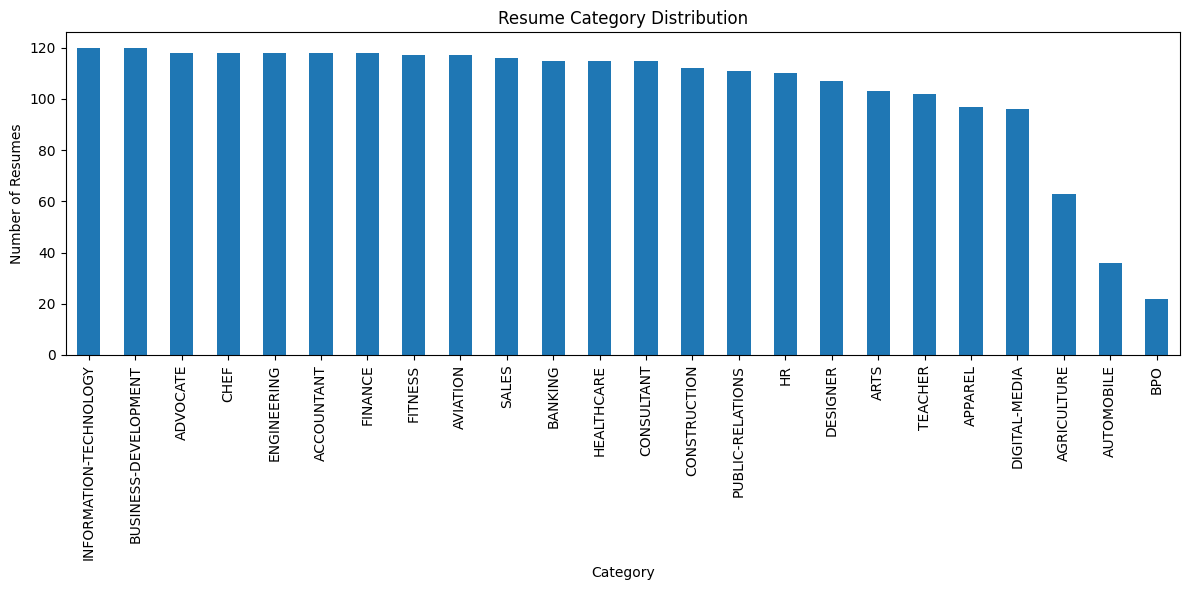

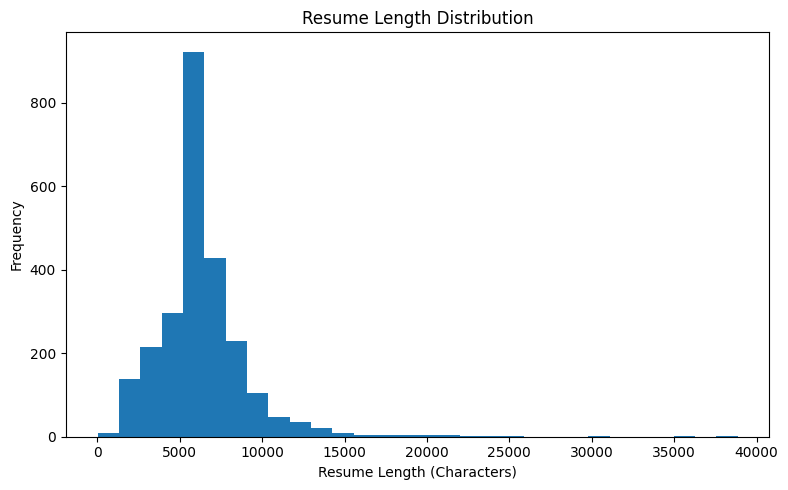

PermissionError: [Errno 13] Permission denied: '../dataset/resume_dataset_phase2.csv'

In [1]:
# ==========================================================
# PHASE 2 : DATASET UNDERSTANDING
# ==========================================================

import pandas as pd

DATASET_PATH = "../dataset/Resume.csv"

# Load Dataset
df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

# Select Required Columns
df = df[["Resume_str", "Category"]]

# Rename Columns
df.columns = ["Resume", "Category"]

print("\nDataset Shape :", df.shape)

print("\nDataset Information")
print("-" * 60)
print(df.info())

print("\nFirst Five Records")
display(df.head())


# ==========================================================
# Dataset Analysis
# ==========================================================

print("=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("Duplicate Rows")
print("=" * 60)
duplicates = df.duplicated().sum()
print(duplicates)

print("\n" + "=" * 60)
print("Unique Categories")
print("=" * 60)

print(df["Category"].value_counts())

print("\nTotal Categories :", df["Category"].nunique())

# Resume Length
df["Resume_Length"] = df["Resume"].astype(str).apply(len)

print("\n" + "=" * 60)
print("Resume Length Statistics")
print("=" * 60)

display(df["Resume_Length"].describe())


# ==========================================================
# Data Visualization
# ==========================================================

import os
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Category Distribution
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

df["Category"].value_counts().plot(kind="bar")

plt.title("Resume Category Distribution")

plt.xlabel("Category")

plt.ylabel("Number of Resumes")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../charts/category_distribution.png",
    dpi=300
)

plt.show()

# ----------------------------------------------------------
# Resume Length Distribution
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    df["Resume_Length"],
    bins=30
)

plt.title("Resume Length Distribution")

plt.xlabel("Resume Length (Characters)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../charts/resume_length_distribution.png",
    dpi=300
)

plt.show()
# ==========================================================
# Save Intermediate Dataset
# ==========================================================

df.to_csv(
    "../dataset/resume_dataset_phase2.csv",
    index=False
)

print("=" * 60)
print("Phase 2 Dataset Saved Successfully")
print("=" * 60)

print("Saved File : ../dataset/resume_dataset_phase2.csv")

# ==========================================================
# Phase 2 Summary
# ==========================================================

print("=" * 60)
print("PHASE 2 COMPLETED")
print("=" * 60)

print(f"""

Dataset Shape        : {df.shape}

Total Categories     : {df['Category'].nunique()}

Missing Values       : {df.isnull().sum().sum()}

Duplicate Rows       : {duplicates}

Average Resume Length: {df['Resume_Length'].mean():.2f}

""")

# Phase 3 – Text Cleaning & Preprocessing

In [2]:
# ==========================================================
# PHASE 3 : TEXT CLEANING & PREPROCESSING
# ==========================================================

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords")

print("=" * 60)
print("Phase 3 : Text Cleaning & Preprocessing")
print("=" * 60)

# ==========================================================
# Load Dataset
# ==========================================================

import pandas as pd

DATASET_PATH = "../dataset/resume_dataset_phase2.csv"

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

display(df.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\G\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Phase 3 : Text Cleaning & Preprocessing
Dataset Loaded Successfully


,Resume,Category,Resume_Length
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,5442
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,5572
2,HR DIRECTOR Summary Over 2...,HR,7720
3,HR SPECIALIST Summary Dedica...,HR,2855
4,HR MANAGER Skill Highlights ...,HR,9172


In [4]:
# ==========================================================
# Text Cleaning Function
# ==========================================================

stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

def clean_resume(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove Email IDs
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove Phone Numbers
    text = re.sub(r"\+?\d[\d\s\-\(\)]{8,}\d", " ", text)

    # Remove HTML Tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove Special Characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove Extra Spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove Stopwords & Apply Stemming
    words = []

    for word in text.split():

        if word not in stop_words:

            words.append(stemmer.stem(word))

    return " ".join(words)

print("Cleaning Function Created Successfully")

Cleaning Function Created Successfully


In [5]:
# ==========================================================
# Apply Text Cleaning
# ==========================================================

df["Clean_Resume"] = df["Resume"].apply(clean_resume)

print("=" * 60)
print("Resume Cleaning Completed")
print("=" * 60)

display(df[["Resume", "Clean_Resume"]].head())

# ==========================================================
# Remove Empty Resumes
# ==========================================================

before = df.shape[0]

df = df[df["Clean_Resume"].str.strip() != ""]

after = df.shape[0]

print("=" * 60)
print("Empty Records Removed")
print("=" * 60)

print("Before :", before)

print("After  :", after)

# ==========================================================
# Encode Categories
# ==========================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Label"] = encoder.fit_transform(df["Category"])

print("=" * 60)
print("Label Encoding Completed")
print("=" * 60)

display(df[["Category", "Label"]].drop_duplicates().sort_values("Label"))

print("\nTotal Classes :", len(encoder.classes_))

# ==========================================================
# Save Label Encoder
# ==========================================================

import os
import joblib

joblib.dump(

    encoder,

    "../model/label_encoder.pkl"

)

print("=" * 60)
print("Label Encoder Saved Successfully")
print("=" * 60)

# ==========================================================
# Save Processed Dataset
# ==========================================================

df.to_csv(

    "../dataset/processed_resume_dataset.csv",

    index=False

)

print("=" * 60)
print("Processed Dataset Saved Successfully")
print("=" * 60)

display(df.head())

# ==========================================================
# Phase 3 Summary
# ==========================================================

print("=" * 60)
print("PHASE 3 COMPLETED")
print("=" * 60)

print(f"""

Dataset Shape       : {df.shape}

Unique Categories   : {df['Category'].nunique()}

Encoded Labels      : {df['Label'].nunique()}

Processed Dataset   : processed_resume_dataset.csv

Saved Encoder       : label_encoder.pkl

Ready For           : Phase 4 (Exploratory Data Analysis)

""")

Resume Cleaning Completed


,Resume,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administr market associ hr administr summar...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr oper summari versatil medi...
2,HR DIRECTOR Summary Over 2...,hr director summari year experi recruit plu ye...
3,HR SPECIALIST Summary Dedica...,hr specialist summari dedic driven dynam year ...
4,HR MANAGER Skill Highlights ...,hr manag skill highlight hr skill hr depart st...


Empty Records Removed
Before : 2484
After  : 2483
Label Encoding Completed


,Category,Label
1808,ACCOUNTANT,0
439,ADVOCATE,1
909,AGRICULTURE,2
1593,APPAREL,3
2264,ARTS,4
1321,AUTOMOBILE,5
2367,AVIATION,6
2149,BANKING,7
972,BPO,8
557,BUSINESS-DEVELOPMENT,9



Total Classes : 24
Label Encoder Saved Successfully
Processed Dataset Saved Successfully


,Resume,Category,Resume_Length,Clean_Resume,Label
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,5442,hr administr market associ hr administr summar...,19
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,5572,hr specialist us hr oper summari versatil medi...,19
2,HR DIRECTOR Summary Over 2...,HR,7720,hr director summari year experi recruit plu ye...,19
3,HR SPECIALIST Summary Dedica...,HR,2855,hr specialist summari dedic driven dynam year ...,19
4,HR MANAGER Skill Highlights ...,HR,9172,hr manag skill highlight hr skill hr depart st...,19


PHASE 3 COMPLETED


Dataset Shape       : (2483, 5)

Unique Categories   : 24

Encoded Labels      : 24

Processed Dataset   : processed_resume_dataset.csv

Saved Encoder       : label_encoder.pkl

Ready For           : Phase 4 (Exploratory Data Analysis)




## PHASE 4 : EXPLORATORY DATA ANALYSIS (EDA)

In [6]:
# ==========================================================
# PHASE 4 : EXPLORATORY DATA ANALYSIS
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DATASET_PATH = "../dataset/processed_resume_dataset.csv"

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("Processed Dataset Loaded Successfully")
print("=" * 60)

print("Dataset Shape :", df.shape)

print("\nUnique Categories :", df["Category"].nunique())

print("\nAverage Resume Length :",
      round(df["Resume"].str.len().mean(),2))

print("\nAverage Clean Resume Length :",
      round(df["Clean_Resume"].str.len().mean(),2))

Processed Dataset Loaded Successfully
Dataset Shape : (2483, 5)

Unique Categories : 24

Average Resume Length : 6297.83

Average Clean Resume Length : 4028.52


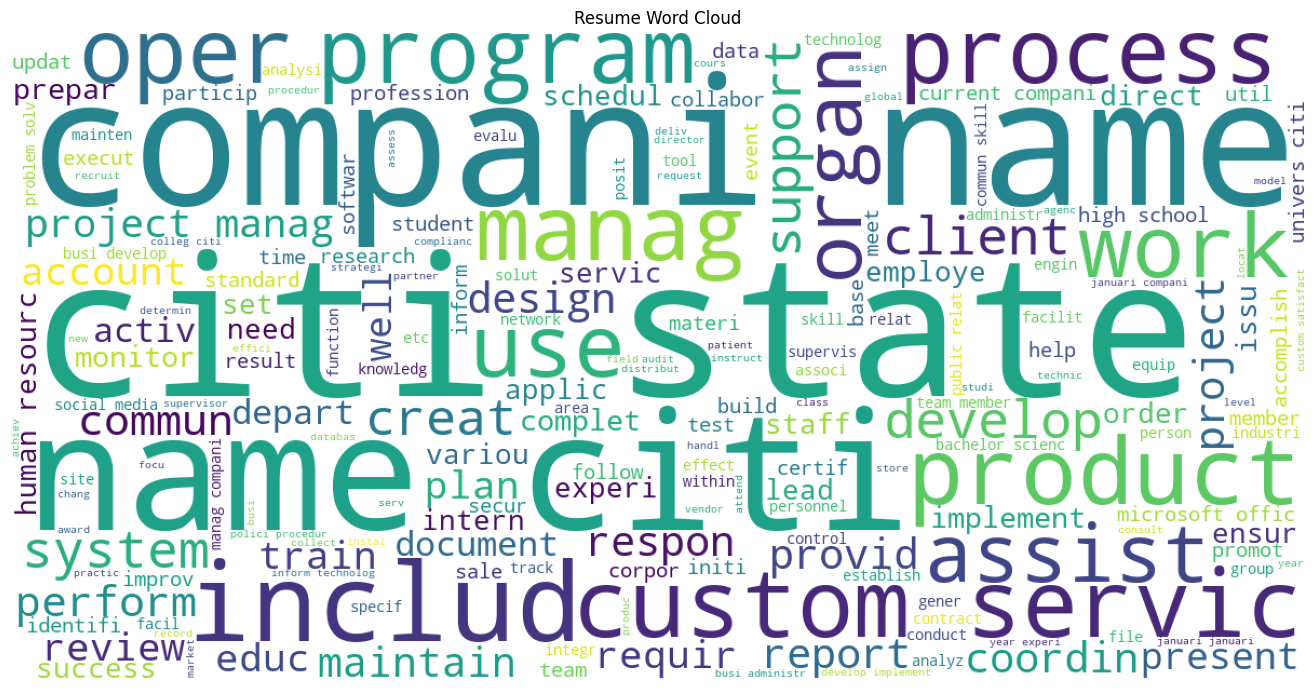

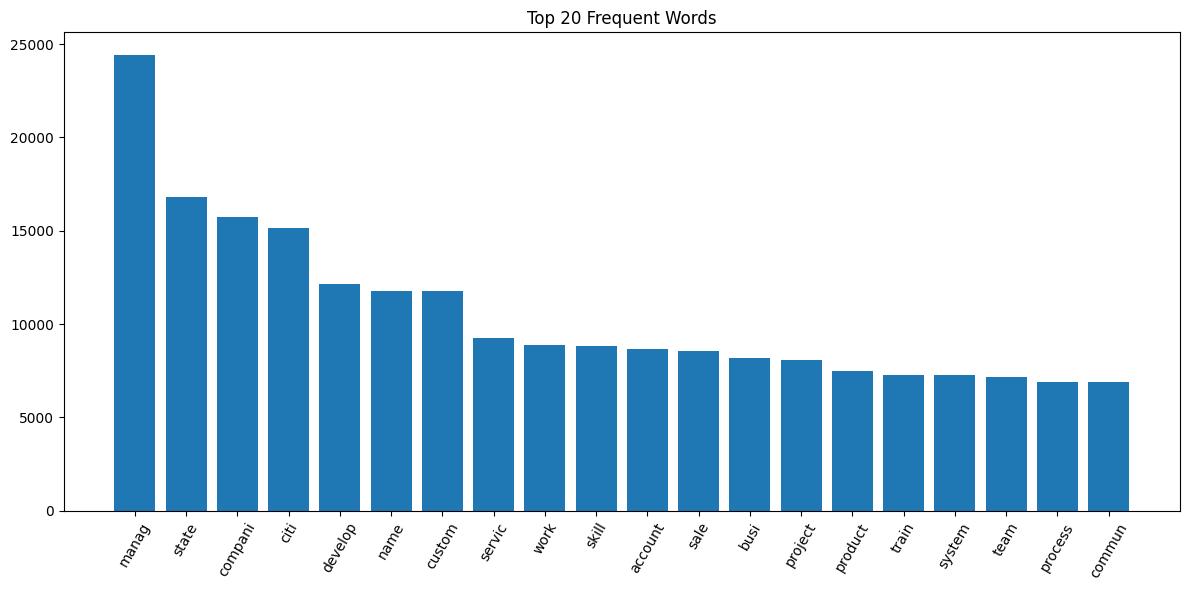

,Word,Frequency
0,manag,24405
1,state,16802
2,compani,15723
3,citi,15128
4,develop,12127
5,name,11792
6,custom,11777
7,servic,9241
8,work,8873
9,skill,8799


In [8]:
# ==========================================================
# Word Cloud & Frequent Words
# ==========================================================

from wordcloud import WordCloud
import os

os.makedirs("../charts", exist_ok=True)

all_text = " ".join(df["Clean_Resume"])

# Word Cloud
wordcloud = WordCloud(

    width=1200,

    height=600,

    background_color="white"

).generate(all_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Resume Word Cloud")

plt.tight_layout()

plt.savefig(
    "../charts/wordcloud.png",
    dpi=300
)

plt.show()

# ----------------------------------------------------------
# Top Frequent Words
# ----------------------------------------------------------

words = all_text.split()

top_words = Counter(words).most_common(20)

top_df = pd.DataFrame(

    top_words,

    columns=["Word","Frequency"]

)

plt.figure(figsize=(12,6))

plt.bar(

    top_df["Word"],

    top_df["Frequency"]

)

plt.xticks(rotation=60)

plt.title("Top 20 Frequent Words")

plt.tight_layout()

plt.savefig(

    "../charts/top_words.png",

    dpi=300

)

plt.show()

display(top_df)

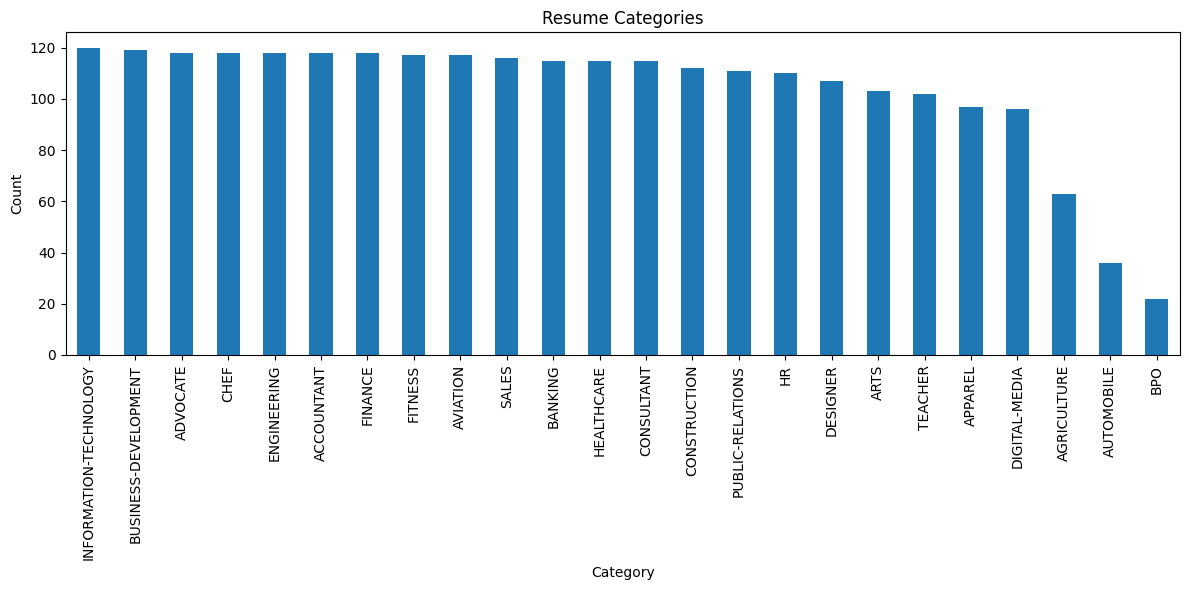

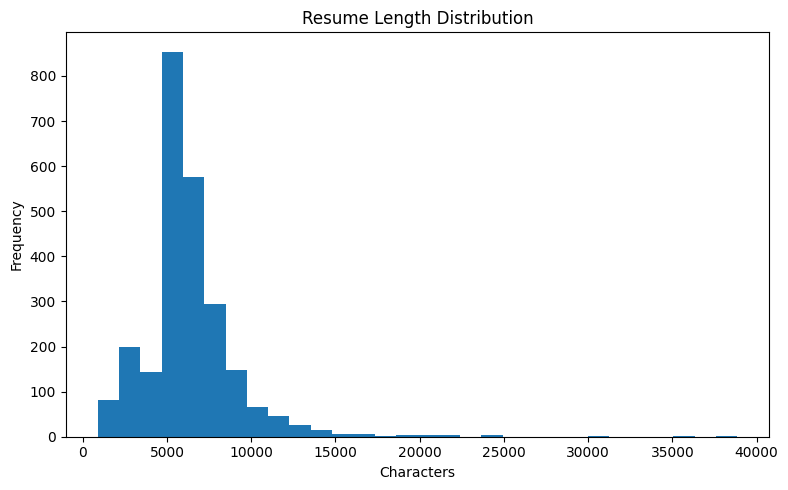

In [9]:
# ==========================================================
# Category Analysis
# ==========================================================

plt.figure(figsize=(12,6))

df["Category"].value_counts().plot(

    kind="bar"

)

plt.title("Resume Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(

    "../charts/category_distribution.png",

    dpi=300

)

plt.show()

# ----------------------------------------------------------
# Resume Length Distribution
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(

    df["Resume"].str.len(),

    bins=30

)

plt.title("Resume Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(

    "../charts/resume_length_distribution.png",

    dpi=300

)

plt.show()

In [11]:
# ==========================================================
# Save EDA Results
# ==========================================================

top_df.to_csv(

    "../dataset/top_20_words.csv",

    index=False

)

print("=" * 60)

print("PHASE 4 COMPLETED")

print("=" * 60)

print("""

Generated Charts

✓ Word Cloud

✓ Top 20 Frequent Words

✓ Resume Category Distribution

✓ Resume Length Distribution

Generated Report

✓ top_20_words.csv

Ready For

Phase 5 : TF-IDF Feature Engineering

""")

PHASE 4 COMPLETED


Generated Charts

✓ Word Cloud

✓ Top 20 Frequent Words

✓ Resume Category Distribution

✓ Resume Length Distribution

Generated Report

✓ top_20_words.csv

Ready For

Phase 5 : TF-IDF Feature Engineering




# PHASE 5 : FEATURE ENGINEERING (TF-IDF)

In [12]:
# ==========================================================
# PHASE 5 : FEATURE ENGINEERING (TF-IDF)
# ==========================================================

import os
import joblib
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

DATASET_PATH = "../dataset/processed_resume_dataset.csv"

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("Processed Dataset Loaded Successfully")
print("=" * 60)

# Remove missing values if any
df["Clean_Resume"] = df["Clean_Resume"].fillna("")

X = df["Clean_Resume"]

y = df["Label"]

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(

    max_features=5000,

    ngram_range=(1,2),

    min_df=2,

    max_df=0.95

)

X_tfidf = tfidf.fit_transform(X)

print("=" * 60)
print("TF-IDF Vectorization Completed")
print("=" * 60)

print("Feature Matrix Shape :", X_tfidf.shape)

Processed Dataset Loaded Successfully
TF-IDF Vectorization Completed
Feature Matrix Shape : (2483, 5000)


In [13]:
# ==========================================================
# Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("=" * 60)

print("Train Test Split Completed")

print("=" * 60)

print("Training Samples :", X_train.shape)

print("Testing Samples  :", X_test.shape)

Train Test Split Completed
Training Samples : (1986, 5000)
Testing Samples  : (497, 5000)


In [16]:
import os
import joblib
import pandas as pd
from scipy import sparse

os.makedirs("../model", exist_ok=True)
os.makedirs("../dataset", exist_ok=True)

# Save vectorizer
joblib.dump(tfidf, "../model/tfidf_vectorizer.pkl")

# Save sparse TF-IDF matrix efficiently
sparse.save_npz("../dataset/tfidf_resume_matrix.npz", X_tfidf)

# Save labels separately
pd.DataFrame({"Label": y.values}).to_csv("../dataset/tfidf_resume_labels.csv", index=False)

print("TF-IDF matrix and labels saved successfully")

TF-IDF matrix and labels saved successfully


In [15]:
# ==========================================================
# Phase 5 Summary
# ==========================================================

print("=" * 60)

print("PHASE 5 COMPLETED")

print("=" * 60)

print(f"""

Original Dataset Shape :

{df.shape}

TF-IDF Feature Matrix :

{X_tfidf.shape}

Training Samples :

{X_train.shape}

Testing Samples :

{X_test.shape}

Vocabulary Size :

{len(tfidf.vocabulary_)}

Saved Files

✓ tfidf_vectorizer.pkl

✓ tfidf_resume_dataset.csv

Ready For

Phase 6 : Model Training & Evaluation

""")

PHASE 5 COMPLETED


Original Dataset Shape :

(2483, 5)

TF-IDF Feature Matrix :

(2483, 5000)

Training Samples :

(1986, 5000)

Testing Samples :

(497, 5000)

Vocabulary Size :

5000

Saved Files

✓ tfidf_vectorizer.pkl

✓ tfidf_resume_dataset.csv

Ready For

Phase 6 : Model Training & Evaluation




## PHASE 6 : MODEL TRAINING & EVALUATION
- Models We'll Compare
- ✅ Logistic Regression
- ✅ Multinomial Naive Bayes
- ✅ Linear SVM
- ✅ Random Forest
- ✅ Decision Tree
- ✅ K-Nearest Neighbors

In [17]:
# ==========================================================
# PHASE 6 : MODEL TRAINING
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Multinomial Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier()

}

results = []

trained_models = {}

print("=" * 60)
print("Training Models")
print("=" * 60)

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    trained_models[name] = model

print("All Models Trained Successfully")

Training Models
All Models Trained Successfully


In [18]:
# ==========================================================
# Model Comparison
# ==========================================================

import pandas as pd

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

).reset_index(drop=True)

display(results_df)

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("=" * 60)

print("Best Model :", best_model_name)

print("=" * 60)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.736419,0.749334,0.736419,0.717079
1,Linear SVM,0.710262,0.716603,0.710262,0.702936
2,Logistic Regression,0.665996,0.669641,0.665996,0.650204
3,KNN,0.581489,0.588439,0.581489,0.565276
4,Decision Tree,0.577465,0.588357,0.577465,0.575766
5,Multinomial Naive Bayes,0.555332,0.612363,0.555332,0.518106


Best Model : Random Forest


In [19]:
# ==========================================================
# Save Best Model
# ==========================================================

import os
import joblib

os.makedirs("../model", exist_ok=True)
os.makedirs("../charts", exist_ok=True)

joblib.dump(

    best_model,

    "../model/resume_classifier.pkl"

)

results_df.to_csv(

    "../charts/model_comparison.csv",

    index=False

)

print("=" * 60)

print("Best Model Saved Successfully")

print("=" * 60)

print("Model :", best_model_name)

print("Saved Files")

print("✓ resume_classifier.pkl")

print("✓ model_comparison.csv")

Best Model Saved Successfully
Model : Random Forest
Saved Files
✓ resume_classifier.pkl
✓ model_comparison.csv


In [20]:
# ==========================================================
# Phase 6 Summary
# ==========================================================

print("=" * 60)

print("PHASE 6 COMPLETED")

print("=" * 60)

print(f"""

Models Trained

✓ Logistic Regression

✓ Multinomial Naive Bayes

✓ Linear SVM

✓ Random Forest

✓ Decision Tree

✓ KNN

Best Model

{best_model_name}

Accuracy

{results_df.iloc[0]['Accuracy']:.4f}

Precision

{results_df.iloc[0]['Precision']:.4f}

Recall

{results_df.iloc[0]['Recall']:.4f}

F1 Score

{results_df.iloc[0]['F1 Score']:.4f}

Saved Files

✓ resume_classifier.pkl

✓ model_comparison.csv

Ready For

Phase 7 : Detailed Model Evaluation & Visualization

""")

PHASE 6 COMPLETED


Models Trained

✓ Logistic Regression

✓ Multinomial Naive Bayes

✓ Linear SVM

✓ Random Forest

✓ Decision Tree

✓ KNN

Best Model

Random Forest

Accuracy

0.7364

Precision

0.7493

Recall

0.7364

F1 Score

0.7171

Saved Files

✓ resume_classifier.pkl

✓ model_comparison.csv

Ready For

Phase 7 : Detailed Model Evaluation & Visualization




# PHASE 7 : MODEL EVALUATION & VISUALIZATION

In [21]:
# ==========================================================
# PHASE 7 : MODEL EVALUATION
# ==========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import pandas as pd
import os

os.makedirs("../charts", exist_ok=True)

# Prediction using Best Model
y_pred = best_model.predict(X_test)

# Classification Report
report = classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
)

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(report)

# Save Report
with open(
    "../charts/classification_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print("\nClassification Report Saved Successfully")

Classification Report
                        precision    recall  f1-score   support

            ACCOUNTANT       0.57      0.83      0.68        24
              ADVOCATE       0.78      0.75      0.77        24
           AGRICULTURE       1.00      0.54      0.70        13
               APPAREL       0.90      0.47      0.62        19
                  ARTS       0.60      0.14      0.23        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.83      0.83      0.83        24
               BANKING       0.74      0.61      0.67        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.73      0.92      0.81        24
                  CHEF       0.87      0.83      0.85        24
          CONSTRUCTION       0.80      0.91      0.85        22
            CONSULTANT       0.83      0.43      0.57        23
              DESIGNER       0.86      0.90      0.88        21
         DIGITAL-

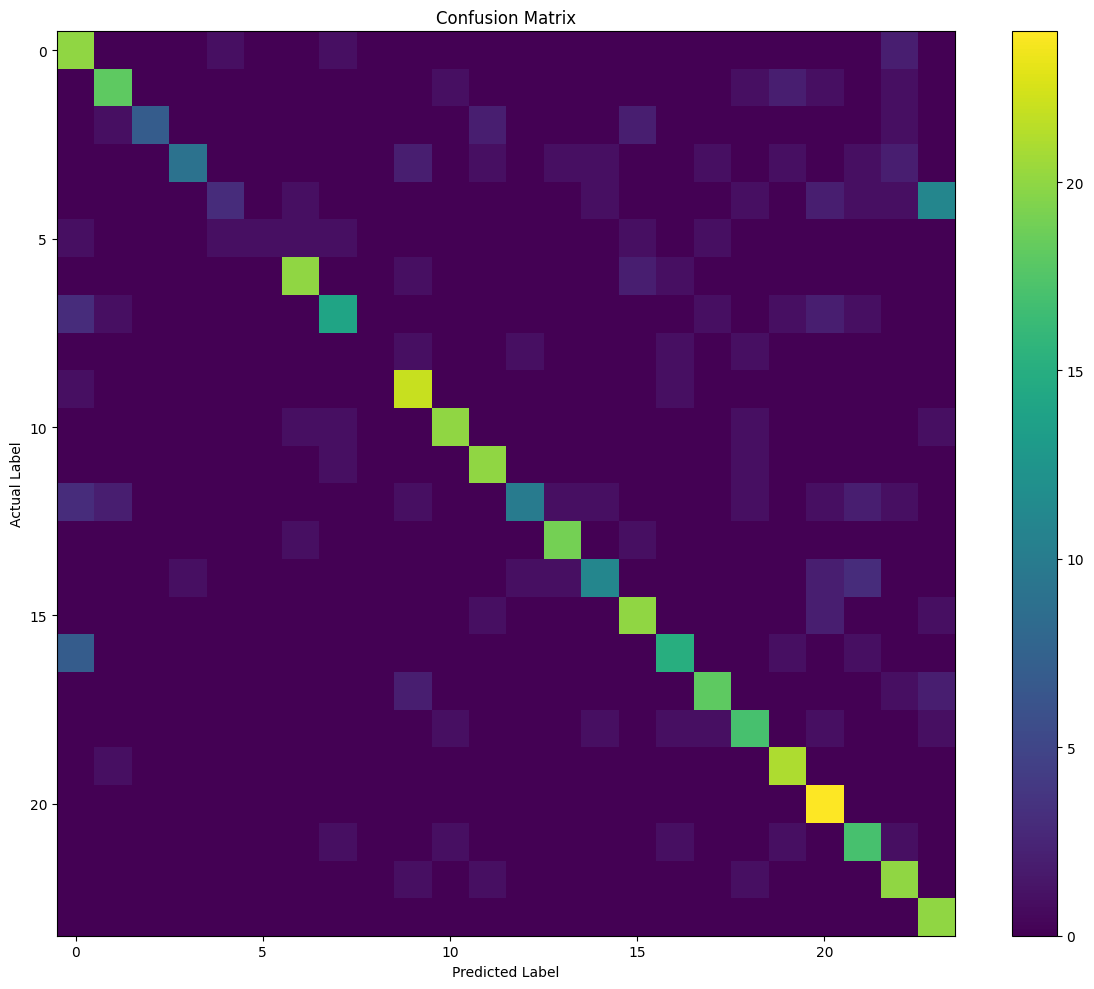

In [22]:
# ==========================================================
# Confusion Matrix
# ==========================================================

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

plt.imshow(
    cm,
    interpolation="nearest",
    aspect="auto"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "../charts/confusion_matrix.png",
    dpi=300
)

plt.show()

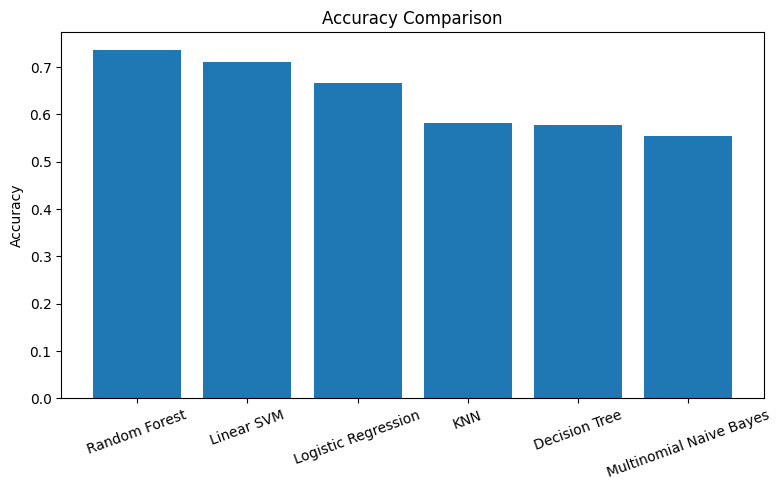

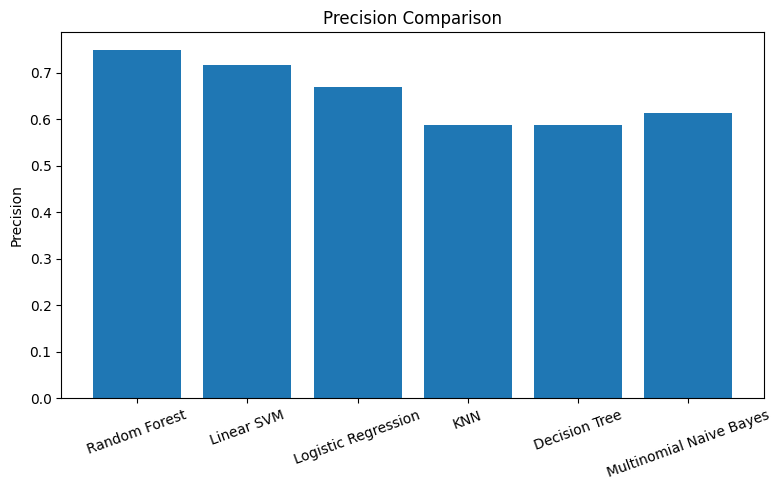

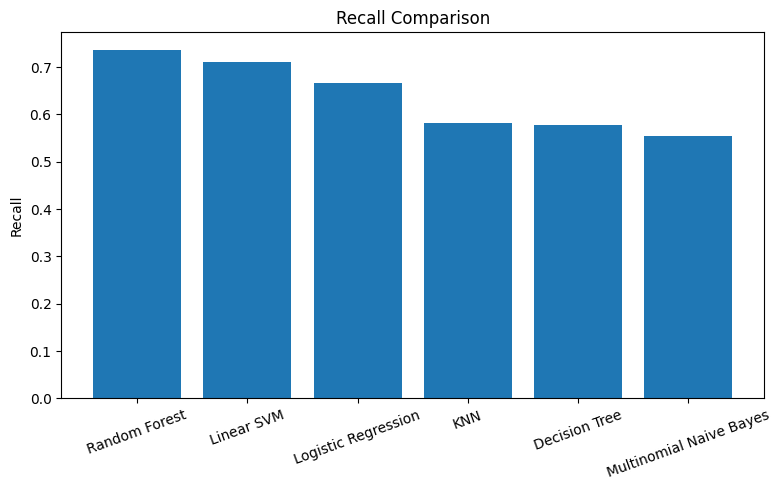

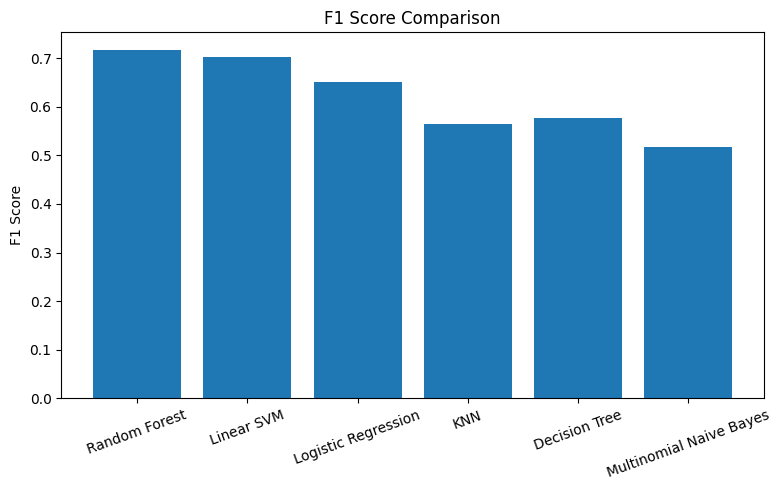

Performance Charts Saved Successfully


In [23]:
# ==========================================================
# Model Comparison Charts
# ==========================================================

import matplotlib.pyplot as plt

os.makedirs("../charts", exist_ok=True)

metrics = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1 Score"

]

for metric in metrics:

    plt.figure(figsize=(8,5))

    plt.bar(

        results_df["Model"],

        results_df[metric]

    )

    plt.title(metric + " Comparison")

    plt.ylabel(metric)

    plt.xticks(rotation=20)

    plt.tight_layout()

    plt.savefig(

        f"../charts/{metric.lower().replace(' ','_')}.png",

        dpi=300

    )

    plt.show()

print("Performance Charts Saved Successfully")

In [ ]:
# ==========================================================
# Save Metrics
# ==========================================================


print("=" * 60)

print("PHASE 7 COMPLETED")

print("=" * 60)

print(f"""

Best Model

{best_model_name}

Accuracy

{results_df.iloc[0]['Accuracy']:.4f}

Precision

{results_df.iloc[0]['Precision']:.4f}

Recall

{results_df.iloc[0]['Recall']:.4f}

F1 Score

{results_df.iloc[0]['F1 Score']:.4f}

Generated Reports

✓ classification_report.txt

✓ model_metrics.csv

Generated Charts

✓ confusion_matrix.png

✓ accuracy.png

✓ precision.png

✓ recall.png

✓ f1_score.png

Ready For

Phase 8 : Streamlit Deployment

""")

PHASE 7 COMPLETED


Best Model

Random Forest

Accuracy

0.7364

Precision

0.7493

Recall

0.7364

F1 Score

0.7171

Generated Reports

✓ classification_report.txt

✓ model_metrics.csv

Generated Charts

✓ confusion_matrix.png

✓ accuracy.png

✓ precision.png

✓ recall.png

✓ f1_score.png

Ready For

Phase 8 : Streamlit Deployment


